In [1]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


df = pd.read_csv('../../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

df = pd.DataFrame(df.groupby('days')['kennedybruecke'].sum())
header = 'kennedybruecke'

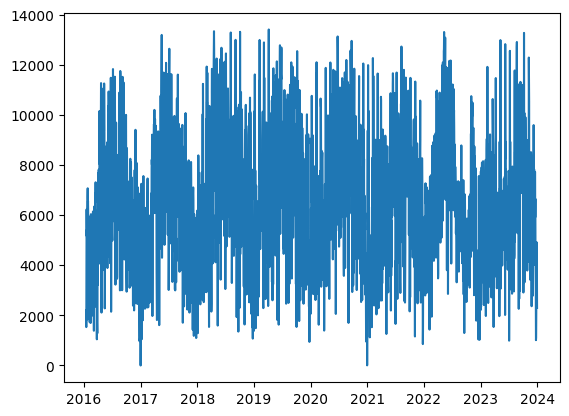

In [2]:
plt.plot(df[header])

In [3]:
df.index = pd.date_range(start=df.index[0], periods=len(df), freq='D')

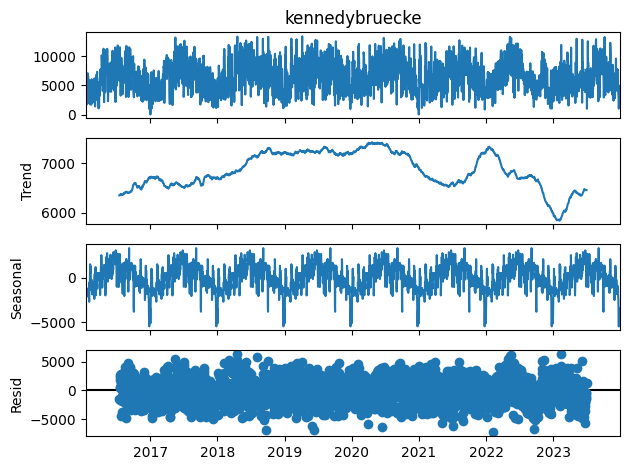

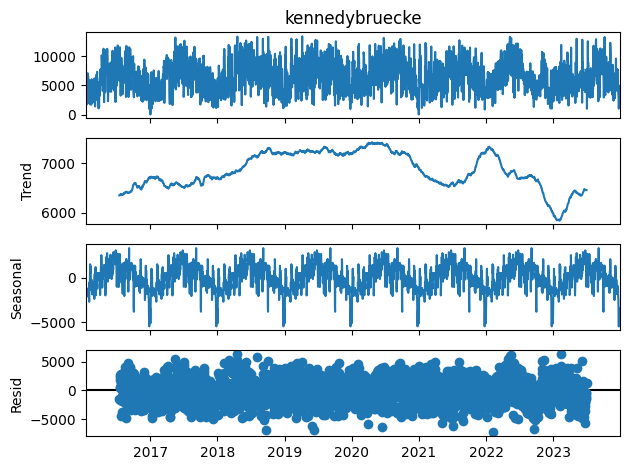

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df[header], period=365)
decomposition.plot()

In [5]:
#probiere logged first differences
from sklearn.preprocessing import MinMaxScaler
import numpy as np


In [6]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
start_date= '2023-03-17'
end_date = '2023-12-31'
future_date='2024-02-28'
#Log Likelyhood: hoch, AIC: niedrig



Seasonal ARIMA

In [7]:
df_unstack = df[[header]]
df_unstack = df_unstack.set_index([df.index.year, df.index.month])
df_unstack.index.rename(['year', 'month'], inplace=True)
df_unstack = df_unstack.groupby(['year', 'month'])[header].apply(lambda x : x.astype(int).sum())
df_unstack = df_unstack.unstack(['month'])
df_unstack

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2016,72192,123487,141401,211634,232711,223142,247797,243278,269091,180288,165473,154398
2017,134774,130781,202978,201958,258693,259029,246584,223262,212776,201019,175723,124805
2018,154831,164067,183071,249200,251517,263973,250629,238372,227598,222998,210519,173180
2019,164508,205825,203343,218147,254748,261274,245107,252735,233356,227536,201898,173183
2020,196682,172305,192434,218057,259887,260501,275996,262594,266179,227221,199606,155742
2021,152323,174454,189411,199321,190138,232026,216494,236892,252307,206681,187332,174689
2022,163386,156977,253585,222104,297967,263419,237817,191570,154743,157666,227418,112062
2023,173889,175447,207031,171770,180301,198583,186218,258426,244494,214720,192657,152345


Monatlich


In [8]:
df_month = df
df_month.set_index([df_month.index.year, df_month.index.month])
df_month['month'] = df_month.index.month
df_month['year'] = df_month.index.year
df_month = df_month.groupby(['year', 'month']).sum().reset_index()
monthly_pattern = df_month.groupby('month')[header].mean()
print(monthly_pattern)

month
1     151573.125
2     162917.875
3     196656.750
4     211523.875
5     240745.250
6     245243.375
7     238330.250
8     238391.125
9     232568.000
10    204766.125
11    195078.250
12    152550.500
Name: kennedybruecke, dtype: float64


In [9]:
df_month.index

RangeIndex(start=0, stop=96, step=1)

In [10]:
df_month['year-month'] = df_month['year'].astype(str) + '-' + df_month['month'].astype(str).str.zfill(2)
tmp = pd.DataFrame()
tmp['year-month'] =  df_month['year-month']
tmp[header] = df_month[header]
df_month = tmp

In [11]:
df_month['year-month'] = pd.to_datetime(df_month['year-month'])
df_month.index = df_month['year-month']
df_month

,year-month,kennedybruecke
year-month,,
2016-01-01,2016-01-01,72192
2016-02-01,2016-02-01,123487
2016-03-01,2016-03-01,141401
2016-04-01,2016-04-01,211634
2016-05-01,2016-05-01,232711
...,...,...
2023-08-01,2023-08-01,258426
2023-09-01,2023-09-01,244494
2023-10-01,2023-10-01,214720


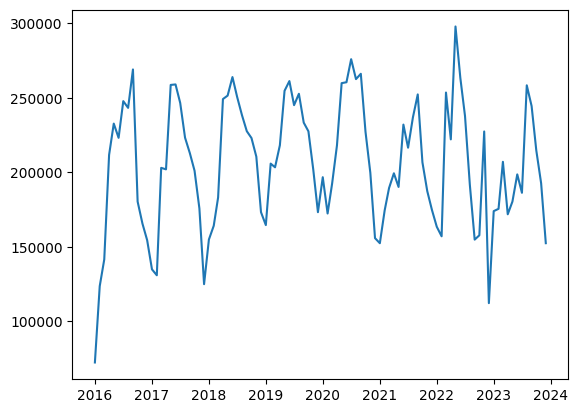

In [12]:
plt.plot(df_month[header])

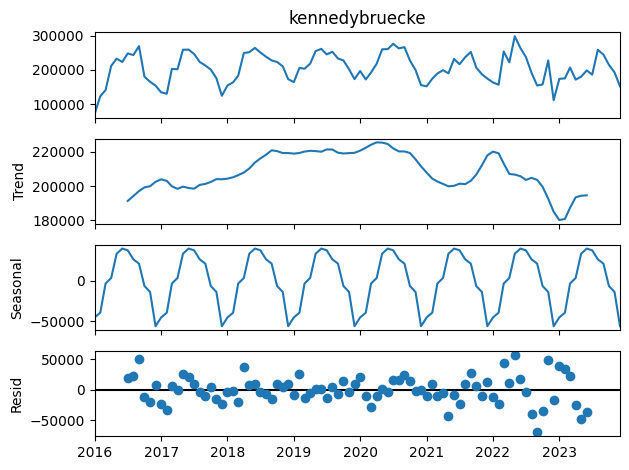

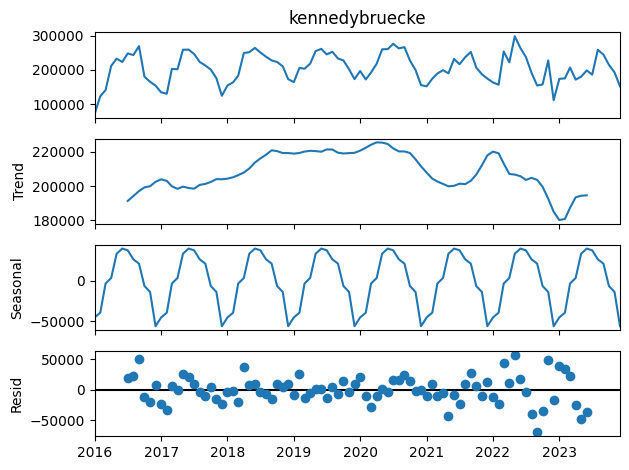

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df_month[header], period=12)
decomposition.plot()

In [14]:
result = adfuller(df_month[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -6.3630
p-value = 0.0000


In [15]:
maximum = max(df_month[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df_month[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df_month['scaled'] = scaled_data
df_month['log'] = np.log(df_month['scaled'])
df_month

,year-month,kennedybruecke,scaled,log
year-month,,,,
2016-01-01,2016-01-01,72192,1.000000,0.000000
2016-02-01,2016-02-01,123487,67697.449873,11.122804
2016-03-01,2016-03-01,141401,91339.407237,11.422338
2016-04-01,2016-04-01,211634,184029.235952,12.122850
2016-05-01,2016-05-01,232711,211845.554774,12.263613
...,...,...,...,...
2023-08-01,2023-08-01,258426,245782.862669,12.412204
2023-09-01,2023-09-01,244494,227396.139993,12.334449
2023-10-01,2023-10-01,214720,188101.976849,12.144740


In [16]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df_month) * 0.9)
df_train = df_month.iloc[:end_train]
df_test = df_month.iloc[end_train:]

In [17]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -2.0818
P-value = 0.2519


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_11164\2308934689.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=12)


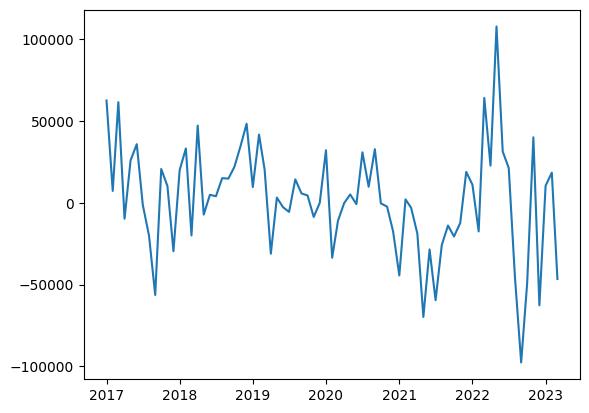

In [18]:
plt.plot(df_train['differences'])

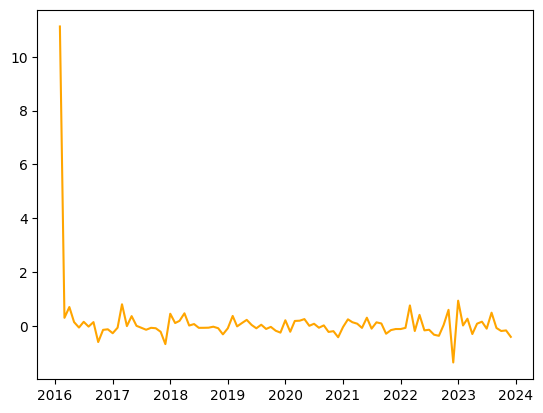

In [19]:
df_month['first_logged_diff'] = df_month['log'].diff().dropna()

plt.plot(df_month['first_logged_diff'], color='orange')
plt.show()

In [20]:
result = adfuller(df_month['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -7.7024
P-value = 0.0000


In [21]:
#Mittelwertbereinigung
df_month['month'] = df_month['year-month'].dt.month
df_month['monthly_mean'] = df_month.groupby('month')['log'].transform('mean')
df_month['cleaned_by_mean'] = df_month['log'] - df_month['monthly_mean']
display(df_month)

,year-month,kennedybruecke,scaled,log,first_logged_diff,month,monthly_mean,cleaned_by_mean
year-month,,,,,,,,
2016-01-01,2016-01-01,72192,1.000000,0.000000,NaN,1,10.214435,-10.214435
2016-02-01,2016-02-01,123487,67697.449873,11.122804,11.122804,2,11.652058,-0.529254
2016-03-01,2016-03-01,141401,91339.407237,11.422338,0.299534,3,11.979425,-0.557087
2016-04-01,2016-04-01,211634,184029.235952,12.122850,0.700512,4,12.110420,0.012430
2016-05-01,2016-05-01,232711,211845.554774,12.263613,0.140763,5,12.286554,-0.022941
...,...,...,...,...,...,...,...,...
2023-08-01,2023-08-01,258426,245782.862669,12.412204,0.490575,8,12.289139,0.123064
2023-09-01,2023-09-01,244494,227396.139993,12.334449,-0.077755,9,12.232827,0.101622
2023-10-01,2023-10-01,214720,188101.976849,12.144740,-0.189709,10,12.054698,0.090041


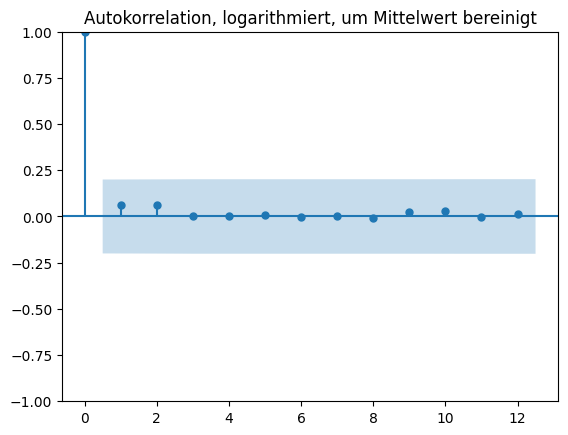

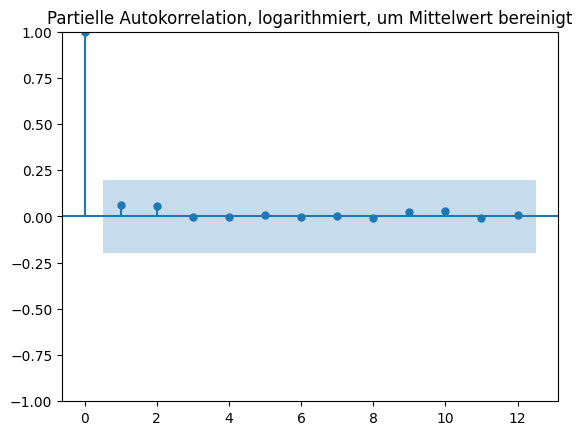

In [22]:
lags  = 12
plot_acf(df_month['cleaned_by_mean'], title='Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plot_pacf(df_month['cleaned_by_mean'], title='Partielle Autokorrelation, logarithmiert, um Mittelwert bereinigt', lags=lags)
plt.show()

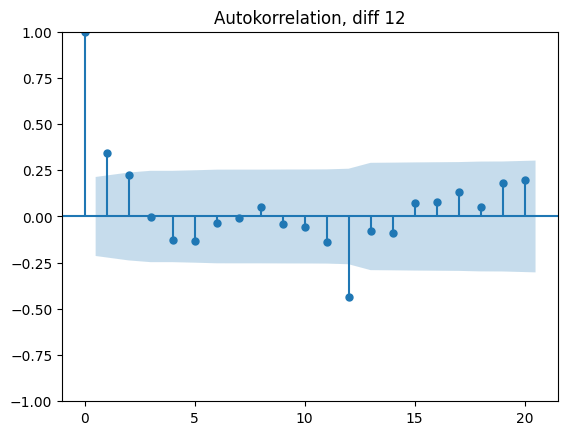

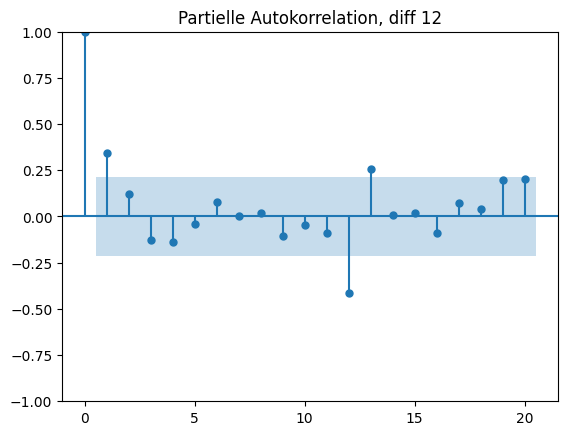

In [23]:
diffs = df_month[header].diff(periods=lags).dropna()
plot_acf(diffs[:], title='Autokorrelation, diff {:}'.format(lags))
plot_pacf(diffs[:], title='Partielle Autokorrelation, diff {:}'.format(lags))
plt.show()

In [24]:
#lags seasonal: 1, lag sonst: 1

end_train = ceil(len(df_month) * 0.9)
df_train_seas = df_month.iloc[:end_train]
df_test_seas = df_month.iloc[end_train:]

df_train_seas = df_train_seas.asfreq('MS')

seasonal = 12
result1 = SARIMAX(df_train_seas['log'], order=(0, 0, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result2 = SARIMAX(df_train_seas['log'], order=(0, 1, 0),
                  seasonal_order=(0, 1, 0, seasonal)).fit()
result3 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 1, seasonal)).fit()
result4 = SARIMAX(df_train_seas['log'], order=(1, 0, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result5 = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result6 = SARIMAX(df_train_seas['log'], order=(0, 0, 1),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
result7 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0,1], seasonal)).fit()
result8 = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(2, 1, 0, seasonal)).fit()

results = [result1, result2, result3, result4, result5]
print('ARIMA (0,0,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result1.llf, result1.aic))
print('ARIMA (0,1,0)x(0,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result2.llf, result2.aic))
print('ARIMA (1,0,0)x(0,1,1,12) LL {:.4f}, AIC: {:.4f}'.format(result3.llf, result3.aic))
print('ARIMA (1,0,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result4.llf, result4.aic))
print('ARIMA (1,1,0)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result5.llf, result5.aic))
print('ARIMA (0,0,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result6.llf, result6.aic))
print('ARIMA (0,1,1)x(0,1,2,12) LL {:.4f}, AIC: {:.4f}'.format(result7.llf, result7.aic))
print('ARIMA (0,1,1)x(2,1,0,12) LL {:.4f}, AIC: {:.4f}'.format(result8.llf, result8.aic))

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible st

ARIMA (0,0,0)x(0,1,0,12) LL -128.1763, AIC: 258.3526
ARIMA (0,1,0)x(0,1,0,12) LL -127.2534, AIC: 256.5068
ARIMA (1,0,0)x(0,1,1,12) LL -127.9753, AIC: 261.9507
ARIMA (1,0,0)x(0,1,2,12) LL -127.9749, AIC: 263.9498
ARIMA (1,1,0)x(0,1,2,12) LL -124.6737, AIC: 257.3474
ARIMA (0,0,1)x(0,1,2,12) LL -128.0888, AIC: 264.1776
ARIMA (0,1,1)x(0,1,2,12) LL -125.8718, AIC: 257.7436
ARIMA (0,1,1)x(2,1,0,12) LL -125.8359, AIC: 259.6718


In [25]:
print(result5.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                     log   No. Observations:                   87
Model:             SARIMAX(1, 1, 0)x(0, 1, [1, 2], 12)   Log Likelihood                -124.674
Date:                                 Tue, 11 Feb 2025   AIC                            257.347
Time:                                         18:18:17   BIC                            266.564
Sample:                                     01-01-2016   HQIC                           261.024
                                          - 03-01-2023                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7737      0.015    -50.471      0.000      -0.804      -0

In [26]:
start_date = '2016-01-01'
end_date = '2024-12-01'
results_final = SARIMAX(df_train_seas['log'], order=(1, 1, 0),
                  seasonal_order=(0, 1, 2, seasonal)).fit()
y_pred_no_update = results_final.predict(start=start_date, end=end_date)
y_pred_no_update = pd.DataFrame(y_pred_no_update)
y_pred_no_update['unlogged'] = np.exp(y_pred_no_update['predicted_mean'])
y_pred_no_update['new_predict'] = scaler.inverse_transform(y_pred_no_update[['unlogged']])
print(y_pred_no_update)

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


            predicted_mean       unlogged    new_predict
2016-01-01        0.000000       1.000000   72192.000000
2016-02-01        0.000000       1.000000   72192.000000
2016-03-01       11.122767   67694.986592  123485.133522
2016-04-01       11.422365   91341.895793  141402.885630
2016-05-01       12.122826  184024.918282  211630.728412
...                    ...            ...            ...
2024-08-01       11.856790  141038.794614  179059.253576
2024-09-01       11.354003   85306.221864  136829.530679
2024-10-01       11.492384   97966.790804  146422.705580
2024-11-01       12.022624  166478.890368  198335.740218
2024-12-01       10.691395   43975.794795  105512.611395

[108 rows x 3 columns]


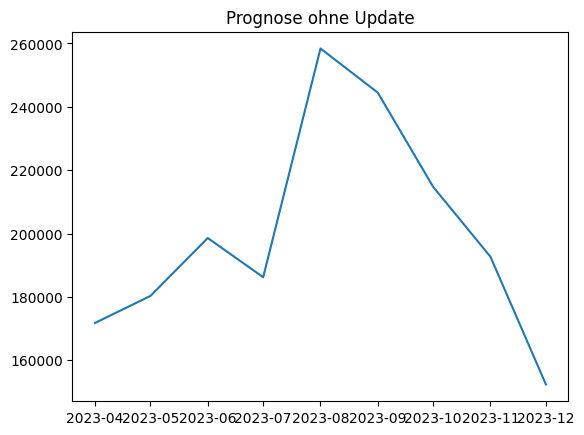

mean absolute error (mae): ARIMA: 61317.6223
mean squared error (mse): ARIMA: 4362746394.4422
mean absolute percentage error (mape): ARIMA: 0.3057


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_11164\1602566024.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
C:\Users\caddowallace\AppData\Local\Temp\ipykernel_11164\1602566024.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
C:\Users\caddowallace\AppData\Local\Temp\ipykern

In [27]:
#plt.plot(y_pred_no_update['new_predict'])
plt.plot(df_test_seas[header])

plt.title('Prognose ohne Update')
plt.show()

plt.show()
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = y_pred_no_update.loc[start_date:end_date, 'new_predict']

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mse_arima = np.mean(np.square(df_test_seas[header] - y_pred_no_update.loc[start_date:'2023-12-01', 'new_predict']))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

In [28]:
arima = SARIMAX(df_train_seas['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0, 1], seasonal), freq='MS')
result = arima.fit()
#print(result.summary())
model = SARIMAX(df_month['log'], order=(0, 1, 1),
                  seasonal_order=(0, 1, [0, 1], seasonal), freq='MS')
result_new = model.filter(result.params)
y_pred_test = result_new.predict(start='2016-01-01', end='2024-12-01')

tmp = pd.DataFrame(y_pred_test)
tmp['unlogged'] = np.exp(tmp['predicted_mean'])
tmp['final_data'] = scaler.inverse_transform(tmp[['unlogged']])

C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'
C:\Users\caddowallace\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


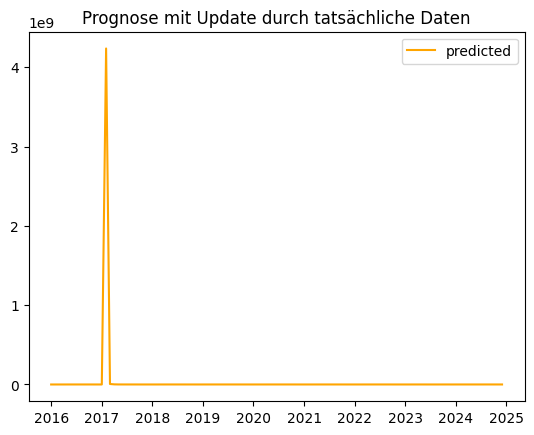

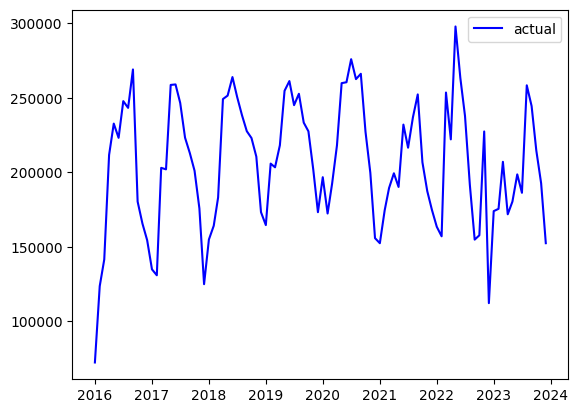

In [29]:
# Mergen der Daten
df_r = pd.concat([df_train_seas, tmp], axis=1)

df_r[header] = df_r[header].fillna(df_r['final_data'])
df_r = pd.DataFrame(df_r)
df_r.index = pd.to_datetime(df_r.index)
start_date = '2016-01-01'
end_date = '2024-12-01'
plt.title('Prognose mit Update durch tatsächliche Daten')
plt.plot(df_r.loc[start_date:end_date, 'final_data'],
           color='orange', label='predicted')
plt.legend()
plt.show()
plt.plot(df_month.loc[start_date:'2023-12-31', header], color='blue', label='actual')
plt.legend()
plt.show()

In [30]:
df_r.loc[start_date:end_date, 'final_data']

2016-01-01     72192.000000
2016-02-01     72192.000000
2016-03-01    123486.523886
2016-04-01    141400.982700
2016-05-01    211633.918487
                  ...      
2024-08-01    354973.625086
2024-09-01    337374.015446
2024-10-01    289466.344251
2024-11-01    251778.550304
2024-12-01    196193.636831
Freq: MS, Name: final_data, Length: 108, dtype: float64

In [31]:
mape_bound = 10

df_test_seas.loc[:, 'intervals'] = (df_test_seas[header] > mape_bound).astype(int).diff().fillna(0).ne(0).cumsum()
df_test_seas.loc[:, 'group'] = df_test_seas[header].apply(lambda x: '≤ 10' if x <= mape_bound else '> 10')
df_test_seas.loc[:, 'predicted'] = df_r.loc[start_date:end_date, header]

greater = df_test_seas[df_test_seas['group'] == '> 10']
mape_arima = []
mape_simple = []

for name, group in greater.groupby('intervals'):
    mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

mae_arima = np.mean(np.abs(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mse_arima = np.mean(np.square(df_test_seas[header] - df_r.loc[start_date:'2023-12-01', header]))
mape_arima = sum(mape_arima) / len(mape_arima)

print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))

mean absolute error (mae): ARIMA: 54244.8635
mean squared error (mse): ARIMA: 4627115855.7717
mean absolute percentage error (mape): ARIMA: 0.2644
